# VHRdb

Exploration of the Viral Host Range database from Pasteur Institute [VRHdb](https://hub.pages.pasteur.fr/viralhostrangedb/)

Only interactions are pressented, unfortunately most of the sources (such as the Félix d'Hérelle collection) do not provide the sequences, only interactions. The phages and hosts with available public sequences have the NCBI identifier given and can be retrieved. 

TODO: Before retrieving anything, check if the sequence / ID is already present with the phagescope metadata. 


**WARNING:** The IDs are sometimes 'str' sometimes 'int'. 


**The Gaborieaux et al data** seems to be accessible somehow on the NCBI even if the records in VHRdb are not linked. Check https://www.ncbi.nlm.nih.gov/bioproject/PRJEB39252/. Check 001-031-c1 -> https://www.ncbi.nlm.nih.gov/datasets/genome/GCA_903971915.1/




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import json
import requests
import re

import os
import warnings

from Bio import Entrez



In [2]:
import requests
import pandas as pd

# Step 1: Download JSON from a URL
def download_json_from_url(url):
    try:
        response = requests.get(url)
        response.raise_for_status()
        return response.json()
    except requests.exceptions.RequestException as e:
        print(f"[ERROR] Failed to fetch JSON from {url}: {e}")
        return None

# Step 2: Convert JSON to DataFrame (with automatic structure detection)
def json_to_df(json_data):
    if json_data is None:
        return None

    # Case 1: JSON has "results" key (e.g., paginated API)
    if isinstance(json_data, dict) and "results" in json_data:
        json_data = json_data["results"]

    # Case 2: JSON is already a list of records
    if isinstance(json_data, list):
        return pd.DataFrame(json_data)

    # Case 3: JSON is a dict of dicts
    if isinstance(json_data, dict):
        return pd.DataFrame.from_dict(json_data, orient='index')

    print("[WARNING] Unrecognized JSON structure; cannot convert to DataFrame.")
    return None

# VHRdb API endpoints
VHRdb_links = {
    "global_scheme": "https://viralhostrangedb.pasteur.cloud/api/global-response/?format=json",
    "agregated_resp": "https://viralhostrangedb.pasteur.cloud/api/aggregated-responses/?allow_overflow=true&format=json",
    "per_data_source": "https://viralhostrangedb.pasteur.cloud/api/responses/?allow_overflow=true&format=json",
    "virus": "https://viralhostrangedb.pasteur.cloud/api/virus/?format=json",
    "host": "https://viralhostrangedb.pasteur.cloud/api/host/?format=json",
    "source": "https://viralhostrangedb.pasteur.cloud/api/data-source/?format=json"
}

# Step 1: Download JSONs
VHRdb_global_scheme_json = download_json_from_url(VHRdb_links["global_scheme"])
VHRdb_agregated_resp_json = download_json_from_url(VHRdb_links["agregated_resp"])
VHRdb_per_data_source_json = download_json_from_url(VHRdb_links["per_data_source"])
VHRdb_virus_json = download_json_from_url(VHRdb_links["virus"])
VHRdb_host_json = download_json_from_url(VHRdb_links["host"])
VHRdb_source_json = download_json_from_url(VHRdb_links["source"])

# Step 2: Convert to DataFrames
VHRdb_global_scheme_df = json_to_df(VHRdb_global_scheme_json)
VHRdb_agregated_resp_df = json_to_df(VHRdb_agregated_resp_json)
VHRdb_per_data_source_df = json_to_df(VHRdb_per_data_source_json)
VHRdb_virus_df = json_to_df(VHRdb_virus_json)
VHRdb_host_df = json_to_df(VHRdb_host_json)
VHRdb_source_df = json_to_df(VHRdb_source_json)

# Step 3: Check format

# Convert VHRdb_agregated_resp_df index to integers
VHRdb_agregated_resp_df.index = VHRdb_agregated_resp_df.index.astype(int)
# Same for columns
VHRdb_agregated_resp_df.columns = VHRdb_agregated_resp_df.columns.astype(int)


In [3]:
VHRdb_virus_df

,name,short_name,identifier,is_ncbi_identifier_value,her_identifier,tax_id,id
0,1,None,KP869100,True,255.0,1508671,308
1,1,None,,False,67.0,None,963
2,10,None,KP869108,True,264.0,1508672,1210
3,109 Lindberg,None,,False,12.0,None,914
4,10 heidelberg,None,,False,437.0,None,1376
...,...,...,...,...,...,...,...
890,χ,None,712913869,False,95.0,None,991
891,ψ,None,,False,305.0,None,1250
892,ψYS40,None,NC_008584,True,473.0,407392,1404
893,ω,None,,False,189.0,None,1139


In [4]:
VHRdb_agregated_resp_df

,15,20,49,50,51,53,54,55,57,591,...,14090,14091,14092,14093,14094,14095,14096,14097,14098,14099
247,"{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
253,"{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 1.0, 'diff': 1}","{'val': 1.0, 'diff': 1}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
254,"{'val': 0.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 2.0, 'diff': 1}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
255,"{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 1.0, 'diff': 1}","{'val': 1.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 2.0, 'diff': 1}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
256,"{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 1.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 2.0, 'diff': 1}",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6358,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"{'val': 1.0, 'diff': 1}","{'val': 1.0, 'diff': 1}","{'val': 1.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 1.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 1.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 2.0, 'diff': 1}"
6359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"{'val': 2.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 2.0, 'diff': 1}"
6360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"{'val': 0.0, 'diff': 1}","{'val': 0.0, 'diff': 1}","{'val': 1.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 1.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 2.0, 'diff': 1}"
6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"{'val': 1.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 1.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 2.0, 'diff': 1}","{'val': 2.0, 'diff': 1}"


Virus IDs and Host IDs in the agregated response seem to intersect, so they have to be treated carefully. 


Attention: ID's are read as strings first -> convert to integers !





In [5]:
virus_agg_ids = VHRdb_agregated_resp_df.index.tolist()
hosts_agg_ids = VHRdb_agregated_resp_df.columns.tolist()

virus_ids = VHRdb_virus_df["id"].tolist()
hosts_ids = VHRdb_host_df["id"].tolist()

# get intersection of virus and hosts
intersection_agg = set(virus_agg_ids).intersection(set(hosts_agg_ids))
intersection_virus_ids = set(hosts_ids).intersection(set(virus_agg_ids))

# Print the IDs
print("Virus IDs from aggregated response:", sorted(virus_agg_ids))
print("Host IDs from aggregated response:", sorted(hosts_agg_ids))
print("Virus IDs from VHRdb virus list:", sorted(virus_ids))
print("Host IDs from VHRdb host list:", sorted(hosts_ids))

# Print the intersection
print("Intersection of virus and hosts IDs:", intersection_agg)
print("Intersection of virus IDs from aggregated response and virus list:", intersection_virus_ids)

print("---------------------------------------------------------------------------")
print("Virus and Hosts with NCBI identifiers")

# Virus IDs with an identifier and is_ncbi_identifier_value = True
VHRdb_virus_ncbi = VHRdb_virus_df[VHRdb_virus_df["is_ncbi_identifier_value"] == True]["id"].tolist()
# Host IDs with an identifier and is_ncbi_identifier_value = True
VHRdb_host_ncbi = VHRdb_host_df[VHRdb_host_df["is_ncbi_identifier_value"] == True]["id"].tolist()
print(f"{len(VHRdb_virus_ncbi)} Virus IDs with NCBI identifier:", sorted(VHRdb_virus_ncbi))
print(f"{len(VHRdb_host_ncbi)} Host IDs with NCBI identifier:", sorted(VHRdb_host_ncbi))

# Now we need to check how many of these IDs are in the aggregated response and have interaction data. 


Virus IDs from aggregated response: [247, 253, 254, 255, 256, 262, 308, 311, 369, 371, 372, 375, 377, 429, 555, 556, 557, 558, 559, 560, 561, 562, 563, 564, 565, 566, 568, 679, 680, 681, 690, 691, 692, 693, 694, 695, 696, 697, 699, 741, 742, 743, 744, 745, 746, 747, 748, 749, 750, 751, 752, 753, 754, 755, 756, 757, 758, 759, 760, 761, 762, 763, 764, 765, 766, 767, 768, 769, 770, 771, 772, 773, 774, 775, 776, 777, 778, 779, 903, 904, 905, 906, 907, 908, 909, 910, 911, 912, 913, 914, 915, 916, 917, 918, 919, 920, 921, 922, 923, 924, 925, 926, 927, 928, 929, 930, 931, 932, 934, 935, 936, 937, 938, 939, 940, 941, 942, 943, 944, 945, 946, 947, 948, 949, 950, 951, 952, 953, 954, 955, 956, 957, 958, 960, 961, 962, 963, 964, 965, 966, 967, 968, 969, 970, 971, 972, 973, 974, 975, 976, 977, 978, 979, 980, 981, 982, 983, 984, 985, 986, 987, 988, 989, 990, 991, 992, 993, 994, 995, 996, 997, 998, 999, 1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012, 1013, 1014, 1015, 10

In [6]:
# Elements with NCBI identifiers in the aggregated response


# Get elements from VHRdb_agregated_resp_df with index in VHRdb_virus_ncbi
vidx_lst = [vid for vid in VHRdb_agregated_resp_df.index if vid in VHRdb_virus_ncbi]
VHRdb_agregated_resp_df_vncbi = VHRdb_agregated_resp_df.loc[vidx_lst]

# filter columns with hosts that have NCBI identifiers, resulting in both virus and host IDs with accessible sequences
hidx_lst = [hid for hid in VHRdb_agregated_resp_df.columns if hid in VHRdb_host_ncbi]
VHRdb_agregated_resp_df_vhncbi = VHRdb_agregated_resp_df_vncbi[hidx_lst]

print(f"Shape of VHRdb_agregated_resp_df with both virus and host NCBI IDs: {VHRdb_agregated_resp_df_vhncbi.shape}")
print(f"There are {len(VHRdb_agregated_resp_df_vhncbi.index)} virus IDs and {len(VHRdb_agregated_resp_df_vhncbi.columns)} host IDs with NCBI identifiers in the aggregated response.")

# Plot the heatmap of interactions: NaN are in grey, {'val': 0.0, 'diff': 1} in green, {'val': 1.0, 'diff': 1} in orange, {'val': 2.0, 'diff': 1} in red. 
# extract the values from the dictionary in the DataFrame if the value is a dictionary
VHRdb_agregated_resp_df_vhncbi_plt = VHRdb_agregated_resp_df_vhncbi.map(lambda x: x['val'] if isinstance(x, dict) else np.nan)
print(f"Existing interaction data: {VHRdb_agregated_resp_df_vhncbi_plt.notnull().sum().sum()}")
print(f"No interaction data data: {VHRdb_agregated_resp_df_vhncbi_plt.isnull().sum().sum()}")




Shape of VHRdb_agregated_resp_df with both virus and host NCBI IDs: (339, 28)
There are 339 virus IDs and 28 host IDs with NCBI identifiers in the aggregated response.
Existing interaction data: 228
No interaction data data: 9264


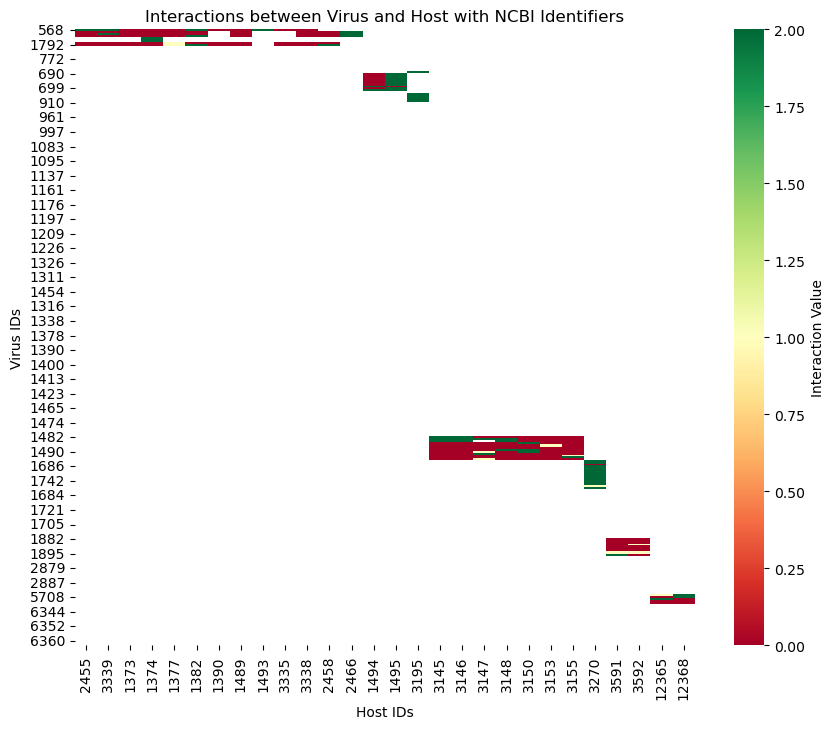

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(VHRdb_agregated_resp_df_vhncbi_plt, cmap="RdYlGn", annot=False, fmt=".1f", cbar_kws={'label': 'Interaction Value'})
plt.title("Interactions between Virus and Host with NCBI Identifiers")
plt.xlabel("Host IDs")
plt.ylabel("Virus IDs")
plt.show()

<Figure size 1000x800 with 0 Axes>

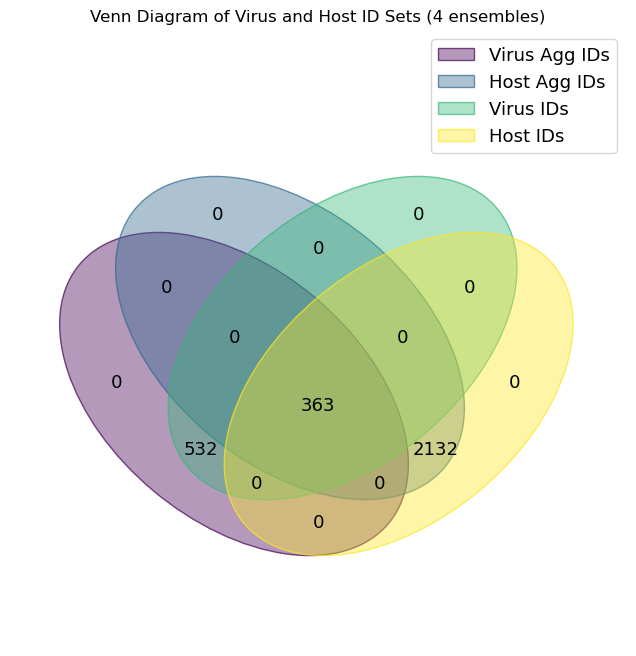

In [8]:
from venn import venn
import matplotlib.pyplot as plt

# Préparation des données pour la bibliothèque `venn`
sets = {
    "Virus Agg IDs": set(virus_agg_ids),
    "Host Agg IDs": set(hosts_agg_ids),
    "Virus IDs": set(virus_ids),
    "Host IDs": set(hosts_ids)
}

# Tracer le Venn diagram à 4 ensembles
plt.figure(figsize=(10, 8))
venn(sets)
plt.title("Venn Diagram of Virus and Host ID Sets (4 ensembles)")
plt.show()


In [9]:
print(sorted(virus_agg_ids))
print(sorted(hosts_agg_ids))
print(sorted(virus_ids))
print(sorted(hosts_ids))

[247, 253, 254, 255, 256, 262, 308, 311, 369, 371, 372, 375, 377, 429, 555, 556, 557, 558, 559, 560, 561, 562, 563, 564, 565, 566, 568, 679, 680, 681, 690, 691, 692, 693, 694, 695, 696, 697, 699, 741, 742, 743, 744, 745, 746, 747, 748, 749, 750, 751, 752, 753, 754, 755, 756, 757, 758, 759, 760, 761, 762, 763, 764, 765, 766, 767, 768, 769, 770, 771, 772, 773, 774, 775, 776, 777, 778, 779, 903, 904, 905, 906, 907, 908, 909, 910, 911, 912, 913, 914, 915, 916, 917, 918, 919, 920, 921, 922, 923, 924, 925, 926, 927, 928, 929, 930, 931, 932, 934, 935, 936, 937, 938, 939, 940, 941, 942, 943, 944, 945, 946, 947, 948, 949, 950, 951, 952, 953, 954, 955, 956, 957, 958, 960, 961, 962, 963, 964, 965, 966, 967, 968, 969, 970, 971, 972, 973, 974, 975, 976, 977, 978, 979, 980, 981, 982, 983, 984, 985, 986, 987, 988, 989, 990, 991, 992, 993, 994, 995, 996, 997, 998, 999, 1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012, 1013, 1014, 1015, 1016, 1072, 1073, 1074, 1075, 1076, 10

## Exploration of sequence availability



In [10]:
VHRdb_virus_df

,name,short_name,identifier,is_ncbi_identifier_value,her_identifier,tax_id,id
0,1,None,KP869100,True,255.0,1508671,308
1,1,None,,False,67.0,None,963
2,10,None,KP869108,True,264.0,1508672,1210
3,109 Lindberg,None,,False,12.0,None,914
4,10 heidelberg,None,,False,437.0,None,1376
...,...,...,...,...,...,...,...
890,χ,None,712913869,False,95.0,None,991
891,ψ,None,,False,305.0,None,1250
892,ψYS40,None,NC_008584,True,473.0,407392,1404
893,ω,None,,False,189.0,None,1139


In [11]:

# Sequences on ncbi are considered as available, so we have 316/556 sequences available for the phages. 
VHRdb_virus_df.groupby("is_ncbi_identifier_value").size()



is_ncbi_identifier_value
False    556
True     339
dtype: int64

In [12]:
# join VHRdb_virus and VHRdb_source on id

VHRdb_virus_source = VHRdb_virus_df.merge(VHRdb_source_df, on="id", how="inner", suffixes=("", "_source"))
VHRdb_virus_source

,name,short_name,identifier,is_ncbi_identifier_value,her_identifier,tax_id,id,name_source,description,public,creation_date,last_edition_date


In [13]:
# df_agregated_resp + VHRdb_virus



In [14]:
# List of id where identifier is available
ncbi_available = VHRdb_virus_df[VHRdb_virus_df["is_ncbi_identifier_value"] == True]["id"].tolist()
print(f"Number of phages with NCBI identifier: {len(ncbi_available)}")
print(f"Phages with NCBI identifier: {ncbi_available}")



Number of phages with NCBI identifier: 339
Phages with NCBI identifier: [308, 1210, 1211, 915, 1212, 772, 1213, 1363, 1155, 1214, 1215, 1391, 1188, 1364, 960, 981, 1228, 1394, 1468, 1205, 1001, 1002, 1174, 980, 311, 994, 1362, 997, 1206, 1004, 1005, 996, 1207, 1006, 1208, 1187, 910, 1175, 777, 1406, 1176, 1395, 1209, 1153, 1154, 1411, 1336, 1158, 1447, 1448, 1449, 1450, 1463, 1451, 1462, 1464, 1452, 1453, 1454, 1455, 1456, 1465, 1471, 1457, 1459, 1460, 1461, 1493, 1492, 1159, 5707, 1428, 1409, 1665, 1666, 1090, 1667, 6361, 995, 1668, 1480, 6347, 1191, 1351, 1161, 1481, 1347, 1389, 1388, 1084, 1320, 1137, 1326, 1670, 1472, 5704, 1379, 1676, 1677, 1678, 1423, 1422, 699, 1416, 1417, 2099, 5767, 5768, 5708, 1172, 1315, 1792, 1791, 6352, 1683, 1684, 1685, 1686, 1687, 1688, 1689, 6341, 1690, 1325, 1194, 1233, 5709, 1473, 1279, 1415, 6355, 6357, 6360, 6343, 1310, 1402, 5710, 5711, 913, 912, 1691, 1692, 1121, 1222, 1132, 1295, 6362, 6359, 1397, 5703, 5702, 1693, 1324, 1338, 773, 1697, 1699, 15

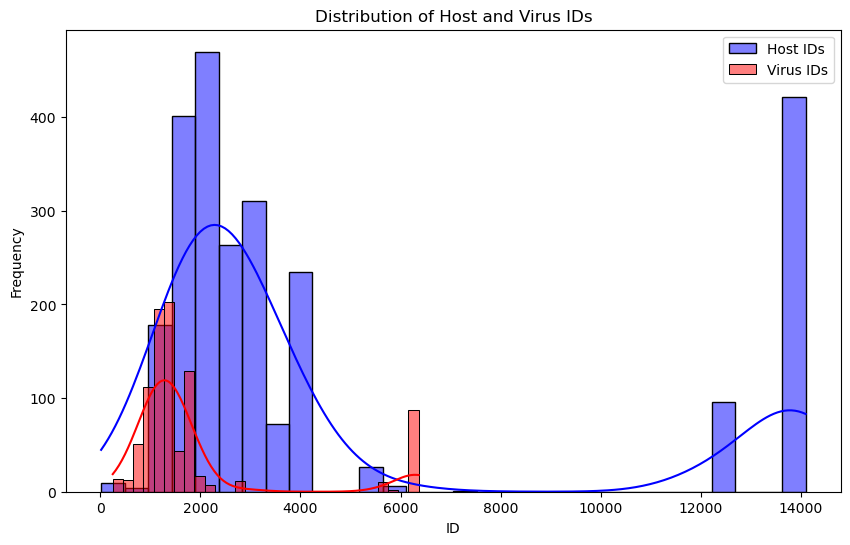

In [15]:
# visualization of the IDs of VHRdb_host["id"] and VHRdb_virus["id"]
plt.figure(figsize=(10, 6))
sns.histplot(VHRdb_host_df["id"], bins=30, kde=True, color='blue', label='Host IDs')
sns.histplot(VHRdb_virus_df["id"], bins=30, kde=True, color='red', label='Virus IDs')
plt.title('Distribution of Host and Virus IDs')
plt.xlabel('ID')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [16]:
# common IDs between VHRdb_host and VHRdb_virus
common_ids = set(VHRdb_host_df["id"]).intersection(set(VHRdb_virus_df["id"]))
print(f"Number of common IDs: {len(common_ids)}")
print(f"Common IDs: {common_ids}")

Number of common IDs: 363
Common IDs: {2099, 2116, 2117, 2118, 2119, 2120, 2121, 2878, 2879, 2880, 2881, 2882, 2883, 2884, 2885, 2886, 2887, 2888, 913, 919, 920, 974, 975, 976, 977, 978, 979, 980, 981, 1210, 1216, 1217, 1218, 1219, 1220, 1221, 1222, 1223, 1224, 1225, 1226, 1227, 1228, 1229, 1230, 1231, 1232, 1233, 1234, 1235, 1236, 1237, 1238, 1239, 1240, 1241, 1242, 1243, 1244, 1245, 1246, 1247, 1248, 1249, 1250, 1251, 1252, 1253, 1254, 1255, 1256, 1257, 1258, 1259, 1260, 1261, 1262, 1263, 1264, 1265, 1266, 1267, 1268, 1269, 1270, 1271, 1272, 1273, 1274, 1275, 1276, 1277, 1278, 1279, 1280, 1281, 1282, 1283, 1284, 1285, 1286, 1287, 1295, 1296, 1297, 1298, 1299, 1300, 1301, 1302, 1303, 1304, 1305, 1306, 1307, 1308, 1309, 1310, 1311, 1312, 1313, 1314, 1315, 1316, 1317, 1318, 1319, 1320, 1321, 1322, 1323, 1324, 1325, 1326, 1327, 1328, 1329, 1330, 1331, 1332, 1333, 1334, 1335, 1336, 1337, 1338, 1339, 1340, 1341, 1342, 1343, 1344, 1345, 1346, 1347, 1348, 1349, 1350, 1351, 1352, 1353, 1354, 

# Try to get ID from Gaborieau isolates identifiers

Hosts might have an NCBI identifier but most don't. It seems that some of the records are stored in the NCBI databases and using the "name" of the host matches the isolate id. However, manually verifying if the records matche the names is not possible. 




In [17]:
from xml.etree import ElementTree

# Replace with your email — required by NCBI
Entrez.email = "your.email@example.com"

def search_ncbi_by_isolate(isolate_id, db="nucleotide", retmax=2000, verbose=True):
    """
    Search NCBI using an isolate identifier and return matching record IDs.

    Parameters:
        isolate_id (str): The isolate identifier to search for.
        db (str): NCBI database to search (default: "nucleotide").
        retmax (int): Maximum number of records to return.
        verbose (bool): Whether to print intermediate information.

    Returns:
        List[str]: List of NCBI IDs (e.g., GenBank accession numbers).
    """

    # Format the search term — using [isolate] tag can help refine
    search_term = f'"{isolate_id}"[Isolate]'

    if verbose:
        print(f"Searching NCBI '{db}' database for: {search_term}")

    # Run the Entrez esearch
    handle = Entrez.esearch(db=db, term=search_term, retmax=retmax)
    results = Entrez.read(handle)
    handle.close()

    ids = results.get("IdList", [])

    if verbose:
        print(f"Found {len(ids)} record(s).")

    return ids

def fetch_summary(ids, db="nucleotide", verbose=True):
    """
    Fetch summaries (titles, accession numbers, etc.) for given NCBI IDs.

    Parameters:
        ids (List[str]): List of NCBI IDs to fetch.
        db (str): Database to fetch from.

    Returns:
        List[dict]: Summary information for each ID.
    """
    if not ids:
        return []

    handle = Entrez.esummary(db=db, id=",".join(ids))
    records = Entrez.read(handle)
    handle.close()

    if verbose:
        for record in records:
            print(f"{record['Caption']} | {record['Title']}")

    return records

# Example usage
if __name__ == "__main__":
    isolate_identifier = "001-031-c1"  # <-- Replace with your isolate ID
    ids = search_ncbi_by_isolate(isolate_identifier, verbose=False)
    print(f"Found IDs: {ids}")
    summaries = fetch_summary(ids)

    

Found IDs: ['2094213945', '2094213944', '2094213943', '2094213942', '2094213941', '2094213940', '2094213939', '2094213938', '2094213937', '2094213936', '2094213935', '2094213934', '2094213933', '2094213932', '2094213931', '2094213930', '2094213929', '2094213928', '2094213927', '2094213926', '2094213925', '2094213924', '2094213923', '2094213922', '2094213921', '2094213920', '2094213919', '2094213918', '2094213917', '2094213916', '2094213915', '2094213914', '2094213913', '2094213912', '2094213911', '2094213910', '2094213909', '2094213908', '2094213907', '2094213906', '2094213905', '2094213904', '2094213903', '2094213902', '2094213901', '2094213900', '2094213899', '2094213898', '2094213897', '2094213896', '2094213895', '2094213894', '2094213893', '2094213892', '2094213891', '2094213890', '2094213889', '2094213888', '2094213887', '2094213886', '2094213885', '2094213884', '2094213883', '2094213882', '2094213881', '2094213880', '2094213879', '2094213878', '2094213877', '2094213876', '2094213

Do not mix isolates and accession number. 

In [18]:
from xml.etree import ElementTree
import re
import time
import pandas as pd

# Replace with your email — required by NCBI
Entrez.email = "your.email@example.com"

def search_ncbi_universal_simple(identifier, db="nucleotide", verbose=True):
    """
    Simplified universal NCBI search without pre-classification.
    """
    if verbose:
        print(f"Searching NCBI '{db}' database for: {identifier}")
    
    # Strategy 1: Direct search (works for most cases)
    try:
        handle = Entrez.esearch(db=db, term=identifier, retmax=10)
        results = Entrez.read(handle)
        handle.close()
        
        ids = results.get("IdList", [])
        if ids:
            if verbose:
                print(f"  Found {len(ids)} record(s) with direct search")
            return ids
    except Exception as e:
        if verbose:
            print(f"  Direct search failed: {e}")
    
    # Strategy 2: Accession field search
    try:
        handle = Entrez.esearch(db=db, term=f"{identifier}[Accession]", retmax=10)
        results = Entrez.read(handle)
        handle.close()
        
        ids = results.get("IdList", [])
        if ids:
            if verbose:
                print(f"  Found {len(ids)} record(s) with accession field search")
            return ids
    except Exception as e:
        if verbose:
            print(f"  Accession field search failed: {e}")
    
    # Strategy 3: Try isolate/strain searches for everything
    isolate_strategies = [
        f'"{identifier}"[Isolate]',
        f'"{identifier}"[Strain]',
        f'"{identifier}"[All Fields]'
    ]
    
    for strategy in isolate_strategies:
        try:
            handle = Entrez.esearch(db=db, term=strategy, retmax=100)
            results = Entrez.read(handle)
            handle.close()
            
            ids = results.get("IdList", [])
            if ids:
                if verbose:
                    print(f"  Found {len(ids)} record(s) with strategy: {strategy}")
                return ids
        except Exception as e:
            if verbose:
                print(f"  Strategy '{strategy}' failed: {e}")
            continue
    
    if verbose:
        print(f"  No records found for {identifier}")
    return []

def fetch_summary(ids, db="nucleotide", verbose=True):
    """
    Fetch summaries (titles, accession numbers, etc.) for given NCBI IDs.
    """
    if not ids:
        return []

    handle = Entrez.esummary(db=db, id=",".join(ids))
    records = Entrez.read(handle)
    handle.close()

    if verbose:
        for record in records:
            print(f"{record['Caption']} | {record['Title']}")

    return records

# Grouping functions
# 
def group_sequences_by_criteria(summaries):
    """Group sequences by various criteria."""
    grouped_data = {
        'by_organism': {},
        'by_length': {'short': [], 'medium': [], 'long': []},
        'by_type': {'complete': [], 'draft': [], 'contig': []},
        'by_source': {}
    }
    
    for record in summaries:
        # Group by organism
        organism = record.get('Organism', 'Unknown')
        if organism not in grouped_data['by_organism']:
            grouped_data['by_organism'][organism] = []
        grouped_data['by_organism'][organism].append(record)
        
        # Group by sequence length
        length = int(record.get('Length', 0))
        if length < 10000:
            grouped_data['by_length']['short'].append(record)
        elif length < 100000:
            grouped_data['by_length']['medium'].append(record)
        else:
            grouped_data['by_length']['long'].append(record)
        
        # Group by sequence type
        title = record.get('Title', '').lower()
        if 'complete' in title:
            grouped_data['by_type']['complete'].append(record)
        elif 'draft' in title:
            grouped_data['by_type']['draft'].append(record)
        else:
            grouped_data['by_type']['contig'].append(record)
        
        # Group by source/submitter
        authors = record.get('Authors', 'Unknown')
        if authors not in grouped_data['by_source']:
            grouped_data['by_source'][authors] = []
        grouped_data['by_source'][authors].append(record)
    
    return grouped_data

def create_summary_dataframe(grouped_data):
    """Create a summary DataFrame from grouped data."""
    summary_list = []
    
    for record in grouped_data.get('all_records', []):
        summary_list.append({
            'accession': record.get('Caption', ''),
            'title': record.get('Title', ''),
            'organism': record.get('Organism', ''),
            'length': int(record.get('Length', 0)),
            'authors': record.get('Authors', ''),
            'create_date': record.get('CreateDate', ''),
            'update_date': record.get('UpdateDate', '')
        })
    
    return pd.DataFrame(summary_list)

def comprehensive_sequence_search_all(isolate_list, output_file=None):
    """
    Search all identifiers and return comprehensive results.
    """
    results = {}
    
    for i, isolate in enumerate(isolate_list):
        print(f"Processing identifier {i+1}/{len(isolate_list)}: {isolate}")
        
        # Add delay to respect NCBI rate limits
        if i > 0:
            time.sleep(0.5)
        
        # Use universal search
        ids = search_ncbi_universal_simple(isolate, verbose=False)
        
        if ids:
            summaries = fetch_summary(ids, verbose=False)
            if summaries:
                grouped = group_sequences_by_criteria(summaries)
                grouped['all_records'] = summaries
                
                results[isolate] = {
                    'total_sequences': len(ids),
                    'ids': ids,
                    'grouped_data': grouped,
                    'dataframe': create_summary_dataframe(grouped)
                }
                
                # Print brief summary
                print(f"  ✓ Found {len(ids)} sequence(s)")
                if summaries:
                    print(f"    Example: {summaries[0]['Caption']} | {summaries[0]['Title'][:60]}...")
            else:
                results[isolate] = {'total_sequences': 0, 'ids': []}
        else:
            results[isolate] = {'total_sequences': 0, 'ids': []}
            print(f"  ✗ No sequences found")
    
    return results

# Extract identifiers from virus and host dataframes
print("Extracting identifiers from VHRdb data...")

# Get virus identifiers with NCBI IDs
virus_ncbi_identifiers = VHRdb_virus_df[
    (VHRdb_virus_df["is_ncbi_identifier_value"] == True) & 
    (VHRdb_virus_df["identifier"].notna())
]["identifier"].tolist()

# Get host identifiers with NCBI IDs
host_ncbi_identifiers = VHRdb_host_df[
    (VHRdb_host_df["is_ncbi_identifier_value"] == True) & 
    (VHRdb_host_df["identifier"].notna())
]["identifier"].tolist()

print(f"Found {len(virus_ncbi_identifiers)} virus identifiers with NCBI")
print(f"Found {len(host_ncbi_identifiers)} host identifiers with NCBI")

# Combine all NCBI identifiers
all_ncbi_identifiers = virus_ncbi_identifiers + host_ncbi_identifiers
print(f"Total NCBI identifiers to search: {len(all_ncbi_identifiers)}")

# Remove duplicates if any
all_ncbi_identifiers = list(set(all_ncbi_identifiers))
print(f"Unique NCBI identifiers: {len(all_ncbi_identifiers)}")

print("\n" + "="*70)
print("Starting comprehensive search for all NCBI identifiers:")
print("="*70)

# Run the search on all identifiers
results_all = comprehensive_sequence_search_all(all_ncbi_identifiers)

# Create summary statistics
print("\n" + "="*50)
print("FINAL SUMMARY:")
print("="*50)

successful = sum(1 for data in results_all.values() if data['total_sequences'] > 0)
total = len(results_all)
total_sequences = sum(data['total_sequences'] for data in results_all.values())

print(f"Success rate: {successful}/{total} ({successful/total*100:.1f}%)")
print(f"Total sequences found: {total_sequences}")
print(f"Average sequences per successful identifier: {total_sequences/successful if successful > 0 else 0:.1f}")

# Detailed breakdown
print("\nDetailed results:")
sequence_counts = []
for isolate, data in results_all.items():
    status = "✓" if data['total_sequences'] > 0 else "✗"
    print(f"{status} {isolate}: {data['total_sequences']} sequences")
    if data['total_sequences'] > 0:
        sequence_counts.append(data['total_sequences'])

# Create summary DataFrame
summary_df = pd.DataFrame([
    {
        'identifier': isolate,
        'found': data['total_sequences'] > 0,
        'num_sequences': data['total_sequences']
    }
    for isolate, data in results_all.items()
])

if sequence_counts:
    print(f"\nSequence count distribution:")
    print(f"Min sequences: {min(sequence_counts)}")
    print(f"Max sequences: {max(sequence_counts)}")
    print(f"Median sequences: {np.median(sequence_counts)}")

# Store results for further analysis
search_results = results_all
search_summary = summary_df

print(f"\nResults stored in variables:")
print(f"- search_results: detailed results dictionary")
print(f"- search_summary: summary DataFrame")

Extracting identifiers from VHRdb data...
Found 339 virus identifiers with NCBI
Found 28 host identifiers with NCBI
Total NCBI identifiers to search: 367
Unique NCBI identifiers: 363

Starting comprehensive search for all NCBI identifiers:
Processing identifier 1/363: KP869102
  ✓ Found 1 sequence(s)
    Example: KP869102 | Escherichia coli O157 typing phage 4, partial genome...
Processing identifier 2/363: NC_022967
  ✓ Found 1 sequence(s)
    Example: NC_022967 | Pseudomonas phage PAK_P2, complete genome...
Processing identifier 3/363: KY629621
  ✓ Found 1 sequence(s)
    Example: KY629621 | Streptococcus virus MS1, complete genome...
Processing identifier 4/363: NC_028883
  ✓ Found 1 sequence(s)
    Example: NC_028883 | Clostridium phage phiMMP01, complete genome...
Processing identifier 5/363: EU863408
  ✓ Found 1 sequence(s)
    Example: EU863408 | Enterobacteria phage JSE, complete genome...
Processing identifier 6/363: NC_023719
  ✓ Found 1 sequence(s)
    Example: NC_023719 | B

KeyboardInterrupt: 

## Compare with the phagescope data

In [ ]:
# Get organism for a specific accession
identifier = "NC_001422"
organisms = search_results[identifier]['grouped_data']['by_organism']
print(f"Organisms for {identifier}: {list(organisms.keys())}")

Organisms for NC_001422: ['Unknown']


In [ ]:
for k in search_results.keys():
    print(f"{k}: {search_results[k]['grouped_data']['by_type']} ")


LN610576: {'complete': [{'Item': [], 'Id': '713662694', 'Caption': 'LN610576', 'Title': 'Pseudomonas phage vB_PaeM_PAO1_Ab17, complete genome', 'Extra': 'gi|713662694|emb|LN610576.1|[713662694]', 'Gi': IntegerElement(713662694, attributes={}), 'CreateDate': '2014/11/10', 'UpdateDate': '2016/06/25', 'Flags': NoneElement(attributes={}), 'TaxId': IntegerElement(1548904, attributes={}), 'Length': IntegerElement(83598, attributes={}), 'Status': 'live', 'ReplacedBy': '', 'Comment': '  ', 'AccessionVersion': 'LN610576.1'}], 'draft': [], 'contig': []} 
MG775043: {'complete': [{'Item': [], 'Id': '1376355127', 'Caption': 'MG775043', 'Title': 'Citrobacter phage vB_CroM_CrRp10, complete genome', 'Extra': 'gi|1376355127|gb|MG775043.2|[1376355127]', 'Gi': IntegerElement(1376355127, attributes={}), 'CreateDate': '2018/02/03', 'UpdateDate': '2018/04/11', 'Flags': NoneElement(attributes={}), 'TaxId': IntegerElement(2079276, attributes={}), 'Length': IntegerElement(168403, attributes={}), 'Status': 'liv